# Final Group Project
## By: Megan Wangsawijaya, Kaci Moy, Trang Kieu, Pete Namchaisiri

### DataSets:
Data set: https://www.kaggle.com/datasets/uciml/el-nino-dataset 

El Nino indices from 1870: https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.csv

## **Dataset Description:**
##### **El Niño Dataset (Kaggle / TAO Array)**
The primary dataset used in this project contains oceanographic and meteorological measurements collected from a network of buoys distributed across the equatorial Pacific Ocean. These measurements were gathered using the Tropical Atmosphere Ocean (TAO) array, which consists of approximately 70 moored buoys designed to monitor large-scale climate conditions.

The data was originally collected by the NOAA Pacific Marine Environmental Laboratory and is available through the UCI Machine Learning Repository. The TAO array plays a critical role in observing environmental variables that influence climate patterns such as El Niño and La Niña, which are part of the El Niño Southern Oscillation (ENSO) system.

This dataset includes a range of environmental features, including:

- Date of observation
- Geographic location (latitude and longitude)
- Zonal wind speed (east–west winds)
- Meridional wind speed (north–south winds)
- Relative humidity
- Air temperature
- Sea surface temperature (SST)
- Subsurface ocean temperatures (down to ~500 meters)

Some buoy locations also record additional variables such as rainfall, solar radiation, and ocean current levels.

The dataset includes observations dating back to approximately 1980, although data availability varies depending on when individual buoys were deployed. Measurements were recorded daily and at consistent times to ensure comparability across observations.

Because this dataset is recorded at a daily frequency, preprocessing was required to align it with the target variable. We aggregated the data to the monthly level by computing average values for each environmental feature.

##### **NOAA dataset:** 
In addition to the buoy dataset, we used a second dataset containing the Niño 3.4 index, which serves as the target variable for our models.

The Niño 3.4 index measures sea surface temperature (SST) anomalies in the central Pacific Ocean and is widely used to monitor and classify ENSO events. It is calculated as a three-month rolling average relative to a long-term climatological baseline.

Threshold values are commonly used to interpret the index:

- Above +0.5 °C → El Niño conditions
- Below −0.5 °C → La Niña conditions

This dataset is reported at a monthly level, which required aligning the buoy data through aggregation before combining the two datasets for modeling.

## **Dataset Limitation:**
- It is also important to note several limitations when working with this dataset. Some variables contain missing values because not all buoys measure every environmental condition. In addition, buoys may shift slightly from their original positions due to ocean movement. While latitude values typically remain within one degree of their intended location, longitude values may sometimes differ by up to five degrees. Finally, some buoys have longer historical records than others because they were installed earlier. Despite these limitations, the dataset provides valuable long-term measurements that can help analyze and predict climate patterns related to El Niño.

## **Our Motivation:**
- We chose this dataset because one of our team members is interested in weather prediction, and we wanted to apply the machine learning concepts we learned in class to a real-world climate problem. In addition, three members of our team come from regions that are affected by El Niño, which made the topic personally meaningful to us. After further research, we found that predicting El Niño events is an important challenge in climate science. El Niño events can significantly influence global weather patterns, often leading to floods, droughts, and shifts in temperature across different regions of the world. By analyzing oceanographic and atmospheric measurements such as sea surface temperature, wind patterns, and humidity, machine learning models may be able to detect patterns associated with the development of El Niño conditions. This makes the dataset both scientifically meaningful and well-suited for building predictive models.

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# Read CSV Data

In [2]:
# read in csv data from Kaggle & NOAA Physical Sciences Laboratory 
elnino = pd.read_csv("elnino.csv") # predictor variables
nino_ind = pd.read_csv("nino34.csv") # target data

In [3]:
elnino.head()

,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp
0,1,80,3,7,800307,-0.02,-109.46,-6.8,0.7,.,26.14,26.24
1,2,80,3,8,800308,-0.02,-109.46,-4.9,1.1,.,25.66,25.97
2,3,80,3,9,800309,-0.02,-109.46,-4.5,2.2,.,25.69,25.28
3,4,80,3,10,800310,-0.02,-109.46,-3.8,1.9,.,25.57,24.31
4,5,80,3,11,800311,-0.02,-109.46,-4.2,1.5,.,25.3,23.19


In [4]:
nino_ind.head()

,Date,NINA34 missing value -99.99 https://psl.noaa.gov/data/timeseries/month/
0,1870-01-01,-1.00
1,1870-02-01,-1.20
2,1870-03-01,-0.83
3,1870-04-01,-0.81
4,1870-05-01,-1.27


## **Research Question:** 
How accurately can machine learning models estimate SST anomalies in order to predict the likelihood of an El Niño event using historical climate and oceanographic data?

## **Problem Formulation:**
This project aims to predict the Niño 3.4 sea surface temperature (SST) anomaly, a continuous variable that reflects deviations from average ocean temperatures in the central Pacific Ocean. Because the target variable is continuous, this task is formulated as a supervised regression problem.

Predicting SST anomalies is important because these values are used to determine the presence of El Niño and La Niña events. In particular, SST anomalies exceeding +0.5 °C typically indicate El Niño conditions, while values below −0.5 °C indicate La Niña conditions.

## **Approach:**
To answer this research question, we use historical oceanographic and atmospheric measurements as input features. These include variables such as wind speeds, humidity, air temperature, sea surface temperature, and subsurface ocean temperatures. We later reiterate and decided to remove some unnecessary/null variables to improve the model.

The project follows three main steps:

- **Model Training:** Train machine learning models on historical data to learn relationships between environmental variables and SST anomalies.

- **Model Evaluation:** Evaluate how accurately the models predict SST anomalies using unseen test data, using metrics such as RMSE.

- **Prediction and Interpretation:** Use predicted SST anomaly values to assess whether conditions meet the threshold for an El Niño event, linking regression outputs to real-world climate classification.

## **Clean Predictor Dataset:**
In this section, we prepare the raw buoy dataset for modeling by cleaning and transforming the data into a usable format. This includes handling missing values, converting variables to numeric types, removing unnecessary columns, and aggregating daily observations into monthly averages. These steps ensure that the predictor data is consistent, properly formatted, and aligned with the monthly Niño 3.4 index used as the target variable.

In [5]:
# remove leading and trailing spaces in column names
elnino.columns = elnino.columns.str.strip()
print(elnino.columns.tolist())

['Observation', 'Year', 'Month', 'Day', 'Date', 'Latitude', 'Longitude', 'Zonal Winds', 'Meridional Winds', 'Humidity', 'Air Temp', 'Sea Surface Temp']


In [6]:
# replace '.' with NaN
elnino = elnino.replace('.', np.nan)

# convert numeric columns where possible
for col in elnino.columns:
    try:
        elnino[col] = pd.to_numeric(elnino[col])
    except:
        pass  # leave non-numeric columns unchanged

# drop Day and Date
elnino = elnino.drop(columns=["Day", "Date", "Observation"])

# # remove data outside of El Niño 3.4 bounds
# elnino = elnino[(elnino['Latitude'] <= -5) | (elnino['Latitude'] >= 5)]
# elnino = elnino[(elnino['Longitude'] >= -170) | (elnino['Longitude'] <= -120)]

# elnino.head()

Above, we commented out the removal of observations with latitudes and longitudes outside the bounds of El Niño 3.4 data. We wanted to test whether the predictions would estimate better with data only coming from the bounds of 3.4 data; however, we found the opposite to be true. Inclusion of data out of the El Niño 3.4 bounds observes more accurate predictions (as we tested with out actual v. prediction graphs). Thus, we decided to keep our predictor data inlusive of all bounds of El Niño.

In [7]:
# elnino.info()

In [8]:
# group by Year and Month, compute means
agg_elnino = elnino.groupby(["Year", "Month"], as_index=False).mean()

# remove humidity -- many NaNs
agg_elnino = agg_elnino.drop(columns=["Humidity"])

# fix Year
agg_elnino.Year = agg_elnino.Year + 1900

In [9]:
agg_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000


In [10]:
agg_elnino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              211 non-null    int64  
 1   Month             211 non-null    int64  
 2   Latitude          211 non-null    float64
 3   Longitude         211 non-null    float64
 4   Zonal Winds       211 non-null    float64
 5   Meridional Winds  211 non-null    float64
 6   Air Temp          211 non-null    float64
 7   Sea Surface Temp  208 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 13.3 KB


## **Clean Target Dataset:**
In this section, we clean and format the Niño 3.4 index dataset to be used as the target variable for our models. This includes extracting year and month from the date field, removing unnecessary columns, renaming variables for clarity, and organizing the data so it can be merged with the predictor dataset.

In [11]:
print(nino_ind.columns.tolist())

['Date', '   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/']


In [12]:
# add Year and Month columns to merge predictor and target data
nino_ind['Year'] = nino_ind['Date'].str.split('-').str[0].astype(int)
nino_ind['Month'] = nino_ind['Date'].str.split('-').str[1].astype(int)

In [13]:
# drop Date columns
nino_ind = nino_ind.drop(columns=["Date"])

In [14]:
# rename indices column
nino_ind = nino_ind.rename(columns={"   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/": "NINA34"})

# reorder columns
nino_ind = nino_ind[['Year', 'Month', 'NINA34']]

In [15]:
nino_ind.head()

,Year,Month,NINA34
0,1870,1,-1.00
1,1870,2,-1.20
2,1870,3,-0.83
3,1870,4,-0.81
4,1870,5,-1.27


In [16]:
nino_ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1872 entries, 0 to 1871
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    1872 non-null   int64  
 1   Month   1872 non-null   int64  
 2   NINA34  1872 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 44.0 KB


## **Merge Predictor & Target Datasets:**
In this section, we combine the cleaned predictor dataset with the Niño 3.4 index dataset using the shared year and month features. This merge creates a single dataset that includes both input variables and the target variable needed for modeling. We then remove any remaining missing values to ensure data quality. Additionally, we create a binary event indicator for exploratory classification, although our primary focus remains on regression.

In [17]:
# merge the data with the El Niño data
clean_elnino = agg_elnino.merge(nino_ind, on=["Year","Month"])

clean_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp,NINA34
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667,0.09
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429,-0.23
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333,-0.12
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129,-0.11
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000,0.10


In [18]:
# drop rows with NaN
clean_elnino = clean_elnino.dropna()

In [19]:
clean_elnino.info()

<class 'pandas.core.frame.DataFrame'>
Index: 208 entries, 0 to 210
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              208 non-null    int64  
 1   Month             208 non-null    int64  
 2   Latitude          208 non-null    float64
 3   Longitude         208 non-null    float64
 4   Zonal Winds       208 non-null    float64
 5   Meridional Winds  208 non-null    float64
 6   Air Temp          208 non-null    float64
 7   Sea Surface Temp  208 non-null    float64
 8   NINA34            208 non-null    float64
dtypes: float64(7), int64(2)
memory usage: 16.2 KB


In [20]:
# add classification target variable if we want to do classification
class_list = []

for index in clean_elnino.NINA34:
    if (index >= 0.05) | (index <= -0.05):
        class_list.append(1)
    else:
        class_list.append(0)

clean_elnino['Event'] = class_list

In [21]:
clean_elnino.head()

,Year,Month,Latitude,Longitude,Zonal Winds,Meridional Winds,Air Temp,Sea Surface Temp,NINA34,Event
0,1980,3,-0.02,-109.46,-3.417391,0.882609,25.793478,25.244667,0.09,1
1,1980,8,0.00,-109.56,-4.319048,2.514286,21.878095,22.201429,-0.23,1
2,1980,9,0.00,-109.56,-4.170000,3.263333,22.167000,22.551333,-0.12,1
3,1980,10,0.00,-109.56,-3.954839,2.174194,21.278387,21.286129,-0.11,1
4,1980,11,0.00,-109.56,-4.923333,4.150000,22.827333,23.379000,0.10,1


We added an Event column that identifies whether an El Niño or La Niña event occured (1) or not (0) within that Month and Year. After training our data with a Random Forest Classifier model, the model was not successful as it always predicted an El Niño or La Niña event. Thus, we will not be using that column further and only utilized it for testing a Random Forest Classifier model. 

## **Algorithm Decision:**

- We used two machine learning approaches: **Linear Regression**, and **Random Forest Regression**. These algorithms were selected to explore both interpretable linear relationships and more complex nonlinear patterns between climate variables and El Niño indicators.
- **Linear Regression** serves as a useful baseline model because it provides a clear and interpretable way to examine how climate variables relate to sea surface temperature (SST) anomalies. Since our goal is to estimate a continuous outcome (the Niño 3.4 SST anomaly index), regression-based methods allow us to quantify how predictors such as zonal winds, meridional winds, air temperature, and sea surface temperature influence SST changes. Linear regression captures linear relationships between these environmental variables and SST anomalies, helping us understand the relative contribution of each feature.
- However, climate systems such as El Niño are driven by complex and nonlinear interactions between atmospheric and oceanic processes. To account for these nonlinear relationships, we also implemented a **Random Forest model**. **Random Forest Regression** allows the model to capture more complex patterns and interactions between variables that linear regression may not detect. Because it builds an ensemble of decision trees, it can model nonlinear relationships and interactions among predictors while reducing overfitting through averaging.
- Ultimately, regression models help estimate the magnitude of SST anomalies.

## **Linear Regression Model:**
In this section, we implement a linear regression model to predict the Niño 3.4 sea surface temperature (SST) anomaly using selected environmental features. We define the input variables (zonal winds, meridional winds, air temperature, and sea surface temperature) and the target variable (SST anomaly), then split the data into training and testing sets. The model is trained on the training data and evaluated on unseen test data using RMSE and R² metrics to assess prediction accuracy

In [22]:
# define model features
features = ['Zonal Winds', 'Meridional Winds', 'Air Temp', 'Sea Surface Temp']

# define X, y
X = clean_elnino[features]
y = clean_elnino['NINA34']

In [23]:
# split training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# fit linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# calculate MSE and r2 score

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Squared Error: 0.2800752581541121
R² Score: 0.5484354911328655


## **Hyperparameter Sensitivity Analysis**

This hyperparameter sensistivity analysis tests whether features including the winds and air temp actually affect El Niño or La Niña events. These weather events are primarily driven by sea surface temperature, as indicated by the index (target variable) that meaasure the changes in sea surface temperature (SST). 

In [25]:
# define model features - we only want Sea Surface Temp
features = ['Sea Surface Temp']

# define X, y
X1 = clean_elnino[features]
y1 = clean_elnino['NINA34']

In [26]:
# split training and testing data
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)

# fit linear regression model
model1 = LinearRegression()
model1.fit(X_train1, y_train1)
y_pred1 = model1.predict(X_test1)

In [ ]:
# calculate MSE and r2 score
rmse1 = root_mean_squared_error(y_test1, y_pred1)
r2_1 = r2_score(y_test1, y_pred1)

print("Root Mean Squared Error:", rmse1)
print("R² Score:", r2_1)

Mean Squared Error: 0.521672212412641
R² Score: 0.1589094376264989


## **Visualizations:**

Based on the MSE and R² Score, the model performed better with all the features as opposed to just Sea Surface Temp. Thus, moving forward, we will use the model with all features including zonal winds, meridional winds, air temp, and sea surface temp.

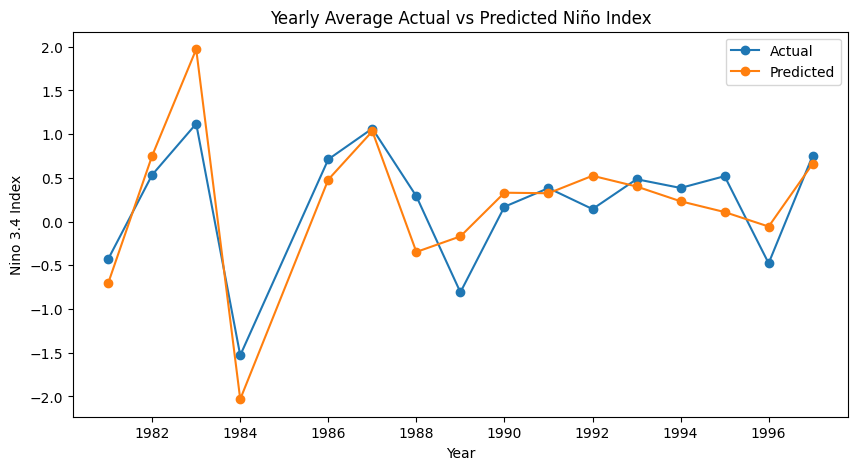

In [28]:
# plot time series actual v. predicted Niño index
results = pd.DataFrame({
    "Year": clean_elnino.loc[y_test.index, "Year"],
    "Actual": y_test,
    "Predicted": y_pred
})

yearly = results.groupby("Year")[["Actual","Predicted"]].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(yearly["Year"], yearly["Actual"], marker='o', label="Actual")
plt.plot(yearly["Year"], yearly["Predicted"], marker='o', label="Predicted")

plt.xlabel("Year")
plt.ylabel("Nino 3.4 Index")
plt.title("Yearly Average Actual vs Predicted Niño Index")

plt.legend()
plt.show()

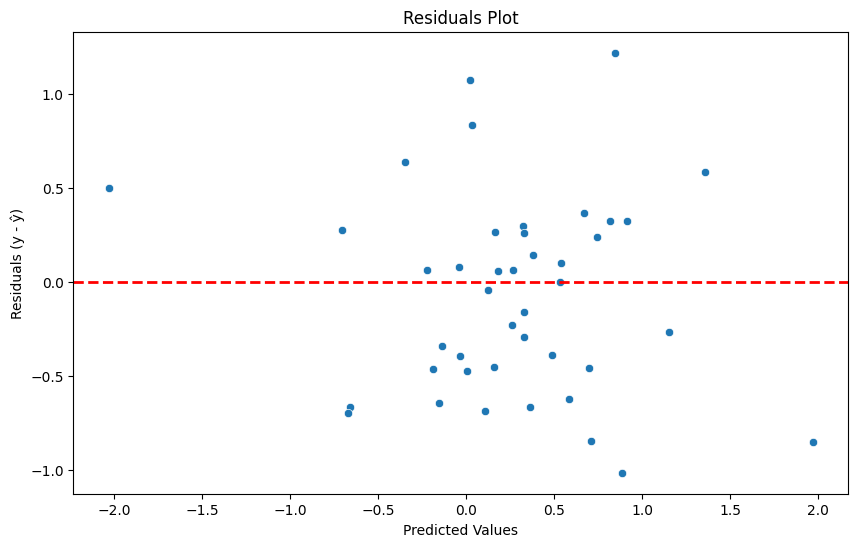

In [29]:
# plot residuals
residuals = y_test - y_pred

plt.figure(figsize = (10, 6))
sns.scatterplot(x = y_pred, y = residuals)
plt.axhline(0, color = 'red', linestyle = '--', linewidth = 2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals Plot")
plt.show()

## **Random Forest Regressor Model:**

In [30]:
# fit random forest regression model
model_rf = RandomForestRegressor()
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

In [ ]:
# calculate MSE and r2 score
rmse2 = root_mean_squared_error(y_test, y_pred_rf)
r2_2 = r2_score(y_test, y_pred_rf)

print("Root Mean Squared Error:", rmse2)
print("R² Score:", r2_2)

Mean Squared Error: 0.27656775285714275
R² Score: 0.5540906315305343


## **Hyperparameter Sensitivity Analysis:**

Similar to the last model, this hyperparameter sensistivity analysis will test whether features including the winds and air temp actually affect El Niño or La Niña events. These weather events are primarily driven by sea surface temperature, as indicated by the index (target variable) that meaasure the changes in sea surface temperature (SST).

In [32]:
# fit random forest regression model
model_rf1 = RandomForestRegressor()
model_rf1.fit(X_train1, y_train1)
y_pred_rf1 = model_rf1.predict(X_test1)

In [ ]:
# calculate MSE and r2 score
rmse1 = root_mean_squared_error(y_test1, y_pred_rf1)
r2_1 = r2_score(y_test1, y_pred_rf1)

print("Root Mean Squared Error:", rmse1)
print("R² Score:", r2_1)

Mean Squared Error: 0.6217203359523813
R² Score: -0.00239785551698124


## **Visualizations**

Based on the MSE and R² Score, the model performed better with all the features as opposed to just Sea Surface Temp. Thus, moving forward, we will use the model with all features including zonal winds, meridional winds, air temp, and sea surface temp.

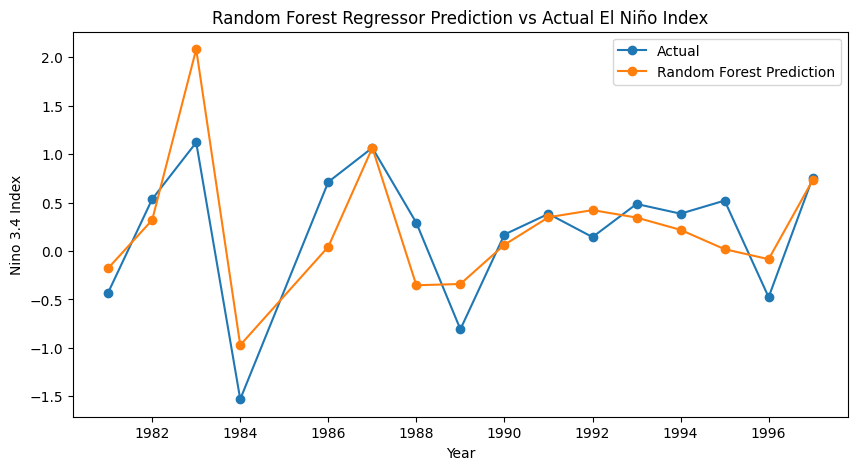

In [34]:
# plot time series actual v. predicted Niño index
results_rf = pd.DataFrame({
    "Year": clean_elnino.loc[y_test.index, "Year"],
    "Actual": y_test,
    "Predicted": y_pred_rf
})

results_rf = results_rf.sort_values("Year")

# Yearly average to reduce noise
yearly_rf = results_rf.groupby("Year")[["Actual","Predicted"]].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(yearly_rf["Year"], yearly_rf["Actual"], marker='o', label="Actual")
plt.plot(yearly_rf["Year"], yearly_rf["Predicted"], marker='o', label="Random Forest Prediction")

plt.xlabel("Year")
plt.ylabel("Nino 3.4 Index")
plt.title("Random Forest Regressor Prediction vs Actual El Niño Index")

plt.legend()
plt.show()

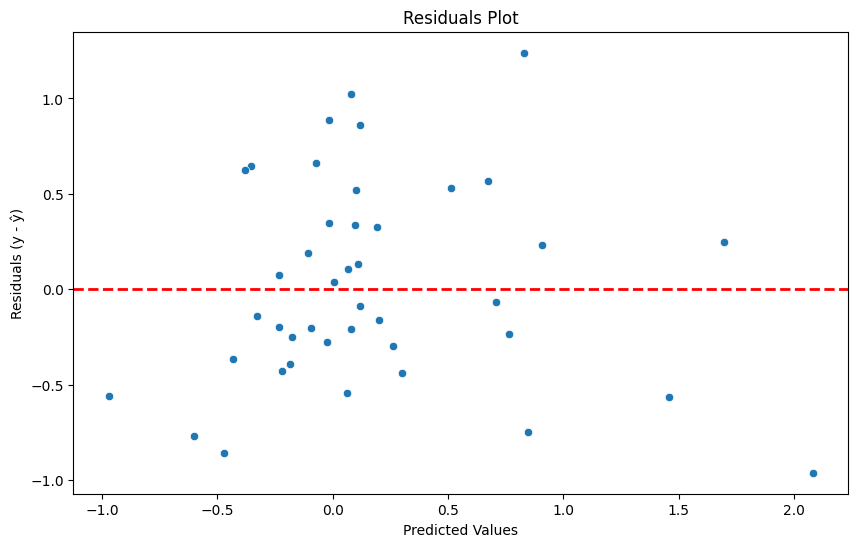

In [35]:
# plot residuals
residuals_rf = y_test - y_pred_rf

plt.figure(figsize = (10, 6))
sns.scatterplot(x = y_pred_rf, y = residuals_rf)
plt.axhline(0, color = 'red', linestyle = '--', linewidth = 2)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals (y - ŷ)")
plt.title("Residuals Plot")
plt.show()

## **Model Evaluation:**
- Initially, we used all the available parameters from the dataset to train the model. The linear regression model reported RMSE of 0.53, while the Random Forest model reported 0.52.
- This number means that on average the prediction will be off by about 0.5 degrees Celsius, which means the models performed rather poorly, considering that in order for an ENSO event to be considered occurring, the Nino 3.4 index has to be greater than 0.5 (for El Nino), or lower than -0.5 (for La Nina) for three consecutive months.  
- As the Nino 3.4 index is basically a representation of the fluctuation of SST at certain parts of the Pacific Ocean, we wondered if we can also predict it with just the SST data. We removed all other features and used only SST to predict the index. The result is that the models with just SST performed significantly worse than their counterparts with all other features with  RMSE of 0.72 and 0.79, respectively.


## **Challenges and Limitation:**
Throughout this project, we encountered several challenges related to the data, modeling approach, and the complexity of the research problem.

- One major challenge was the inherent uncertainty of climate and weather systems. Phenomena such as El Niño are influenced by complex interactions between atmospheric and oceanic processes that occur across large spatial and temporal scales. Because of this, it is difficult for machine learning models especially relatively simple ones to capture all relevant factors. This complexity limits predictive performance and introduces uncertainty into the results.

- Another challenge involved integrating the two datasets used in this project. The buoy dataset contains daily measurements, while the Niño 3.4 index is reported at a monthly level. To combine these datasets, we aggregated daily observations into monthly averages. However, this process required careful consideration and may have resulted in the loss of important short-term variations that could influence model accuracy.

- We also faced limitations related to dataset size. After aggregation, the final dataset contained only 211 observations, which is relatively small for training machine learning models. This limited data availability may reduce the model’s ability to learn complex patterns and generalize effectively to unseen data.

- In addition, we experimented with multiple modeling approaches before identifying methods that produced meaningful results. We initially implemented linear regression as a baseline and later explored Random Forest models to capture nonlinear relationships. This process involved iterative adjustments to both preprocessing and model selection.

To address these challenges in future work, we could incorporate larger and more comprehensive climate datasets, include additional environmental variables, and extend the time range of observations. Additionally, more advanced models—particularly time-series approaches could better capture the temporal dynamics of climate systems such as El Niño and improve predictive performance.

## **Model Impacts, Risks, and Societal Implications:**
Our model answers the research question by predicting the Niño 3.4 SST anomaly using historical climate data. These predicted values can then be used to determine whether El Niño conditions are likely, based on standard thresholds (±0.5 °C).

One advantage of this approach is that it can detect patterns in climate data and potentially support early warning systems. However, because the model is trained on a small dataset and simplified features, it may not generalize well to unseen data or changing climate conditions.

If the model is wrong, it could lead to poor preparation for extreme weather events or unnecessary allocation of resources. If it is accurate, it can help improve planning in areas such as agriculture, disaster response, and water management.

Overall, the model has positive societal impacts in improving climate prediction and preparedness, but negative impacts may arise if there is overreliance on a model with limited accuracy. Therefore, it should be used alongside other scientific methods like statistical model.

## **Future Research Question:**
**How does incorporating longer historical time windows (e.g., multi-year climate trends) affect the accuracy of El Niño predictions?**

El Niño is influenced by slow-moving ocean processes such as subsurface heat buildup and long-term climate oscillations. Our current model relies on short-term (three-month) SST anomalies, which may not fully capture these longer patterns. Exploring multi-year trends could improve prediction accuracy and help determine how much historical context is necessary for reliable climate forecasting.